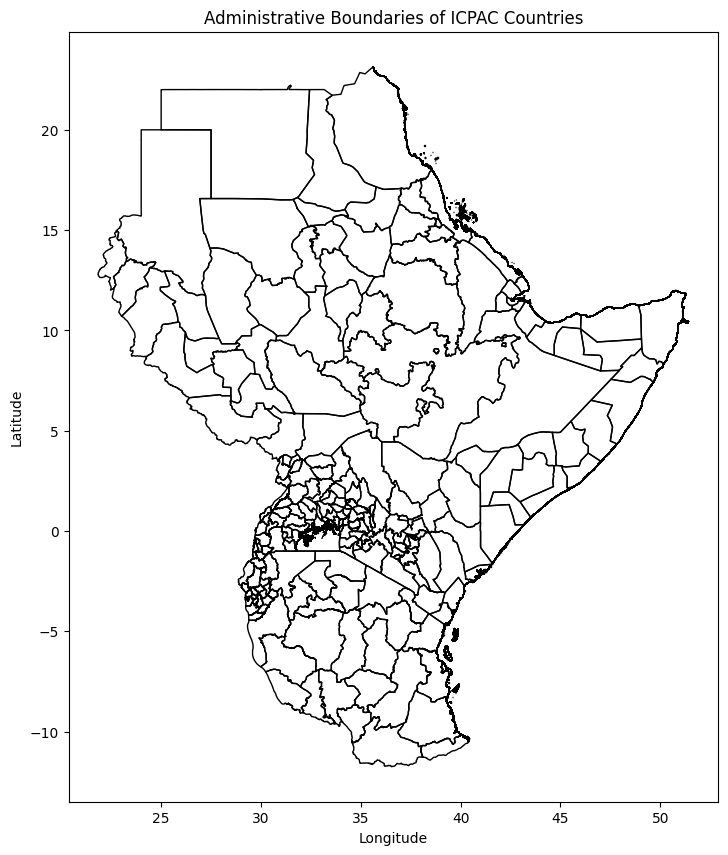

In [11]:
import geopandas as gpd

gd = gpd.read_file("/Users/mac/Documents/analysis/Drought_Monitoring/cdi_analysis/cdi_input/Administrative1_Boundaries_ICPAC_Countries.shp")
# print(gd.head())

# Visualize the geometries
import matplotlib.pyplot as plt
gd.plot(figsize=(10, 10), edgecolor="black", facecolor="none")
plt.title("Administrative Boundaries of ICPAC Countries")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(False)
plt.show()

# CDI Hexagonal Map — April 2020\n\nUsing the `cdi_hexmap.py` engine to generate an interactive H3 hexagonal drought map.

### Step 1 — Import the CDI Hex Engine and configure

In [1]:
from cdi_hexmap import CDIConfig, generate_cdi_hex_map

RASTER_PATH = "cdi_monthly/2020/eadw-cdi-data-2020-apr.tif"
OUTPUT_HTML = "cdi_output/hexmaps/CDI_HexMap_2020_04.html"

config = CDIConfig(
    coarse_resolution=6,
    fine_resolution=8,
    aggregation_method="mode",
    by_category=True,
    opacity=0.75,
)

### Step 2 — Generate the hex map

In [2]:
generate_cdi_hex_map(
    raster_path=RASTER_PATH,
    output_html=OUTPUT_HTML,
    config=config,
)

Extracting raster pixels...
Aggregating coarse resolution...
Map saved → cdi_output/hexmaps/CDI_HexMap_2020_04.html


### Step 3 — Display the map inline

In [3]:
from IPython.display import IFrame
IFrame(src=OUTPUT_HTML, width="100%", height=600)

### Step 4 — Inspect the raw data (optional)

In [4]:
from cdi_hexmap import RasterProcessor, H3Aggregator, CDI_CATEGORY_MAP

# Extract pixels
lats, lngs, values = RasterProcessor.extract_valid_pixels(RASTER_PATH)
print(f"Total valid pixels: {len(values):,}")
print(f"Drought pixels (CDI >= 1): {(values >= 1).sum():,}")

# Show aggregation at coarse resolution
agg = H3Aggregator(config.coarse_resolution)
h3_indices = agg.latlngs_to_h3(lats, lngs)
df = agg.aggregate(h3_indices, values, method="mode", by_category=True)
print(f"Coarse hexagons (res {config.coarse_resolution}): {len(df):,}")
df.head(10)

Total valid pixels: 5,019,500
Drought pixels (CDI >= 1): 102,500
Coarse hexagons (res 6): 165,526


,h3_index,cdi_class,count,lat,lng
0,863ec0007ffffff,No Drought,35,20.851229,27.130771
1,863ec000fffffff,No Drought,36,20.827043,27.192753
2,863ec0017ffffff,No Drought,35,20.813276,27.076801
3,863ec001fffffff,No Drought,36,20.789115,27.138780
4,863ec0027ffffff,No Drought,38,20.913360,27.122754
5,863ec002fffffff,No Drought,35,20.889166,27.184772
6,863ec0037ffffff,No Drought,40,20.875398,27.068755
7,863ec0047ffffff,No Drought,36,20.840729,27.308705
8,863ec004fffffff,No Drought,38,20.816486,27.370619
9,863ec0057ffffff,No Drought,37,20.802841,27.254699


### Step 5 — Generate animated hexagon zoom GIF

In [ ]:
from make_gif import generate_gif

gif_path = generate_gif(
    raster_path=RASTER_PATH,
    resolutions=[3, 4, 5, 6, 7],
    frames_per_res=3,
)

In [ ]:
# Display the GIF inline
from IPython.display import Image as IPImage, display
display(IPImage(filename=gif_path))